## Environment Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Optional: Makes the matplotlib charts look slightly more modern in Jupyter
plt.style.use('ggplot')

## Data Ingestion & Temporal Parsing

In [2]:
# 1. Ingest the cleaned data from Day 1
df = pd.read_csv('structured_logs.csv')

# 2. Convert 'dumb text' into mathematical Datetime objects
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 3. Print the Datatypes to guarantee the conversion worked, then show the first 3 rows
print(df.dtypes, "\n")
df.head(3)

timestamp      datetime64[us]
ip_address                str
endpoint                  str
status_code           float64
dtype: object 



,timestamp,ip_address,endpoint,status_code
0,2026-06-01 00:00:00,192.168.1.254,/api/billing,200.0
1,2026-06-01 00:00:10,UNKNOWN_IP,/api/users,500.0
2,2026-06-01 00:00:20,192.168.1.96,/api/users,200.0


## The Intelligence Layer (Aggregation)
This compresses thousands of rows into actionable intelligence.

In [3]:
# Aggregation 1: Server Health (Counting HTTP Status Codes)
print("--- SERVER HEALTH SUMMARY ---")
health_summary = df['status_code'].value_counts()
print(health_summary)

print("\n--- TRAFFIC BY ENDPOINT ---")
# Aggregation 2: Group by endpoint, count occurrences, sort highest to lowest
traffic_summary = df.groupby('endpoint').size().sort_values(ascending=False)
print(traffic_summary.head(5))

--- SERVER HEALTH SUMMARY ---
status_code
200.0    65180
502.0     9366
404.0     9329
500.0     9213
0.0       1912
Name: count, dtype: int64

--- TRAFFIC BY ENDPOINT ---
endpoint
/api/login      23891
/api/users      23800
/api/billing    23713
/api/data       23596
dtype: int64


## The Visualization Layer
This takes the aggregated variables from Cell 3 and plots them onto a digital canvas

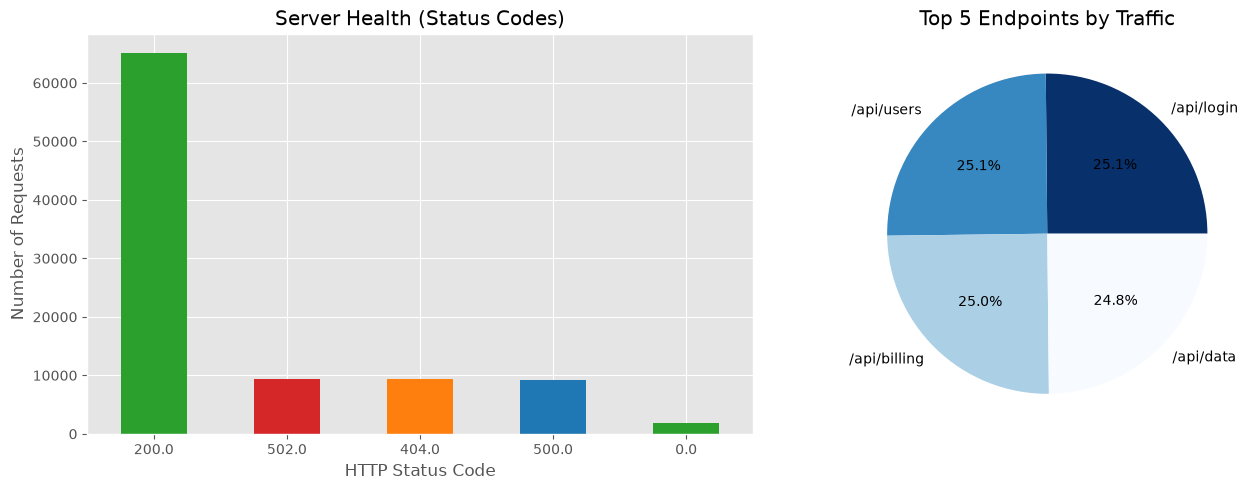

In [4]:
# Spawn a digital canvas with two empty side-by-side slots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart for Status Codes on the left slot (axes[0])
health_summary.plot(kind='bar', ax=axes[0], color=['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4'])
axes[0].set_title('Server Health (Status Codes)')
axes[0].set_xlabel('HTTP Status Code')
axes[0].set_ylabel('Number of Requests')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Pie chart for Top 5 Endpoints on the right slot (axes[1])
traffic_summary.head(5).plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colormap='Blues_r')
axes[1].set_title('Top 5 Endpoints by Traffic')
axes[1].set_ylabel('')

# Render the canvas
plt.tight_layout()
plt.show()